# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `results.tsv`.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, val_auc, num_features, status, description)
df = pd.read_csv("results.tsv", sep="\t")
df["val_auc"] = pd.to_numeric(df["val_auc"], errors="coerce")
df["num_features"] = pd.to_numeric(df["num_features"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 20
Columns: ['commit', 'val_auc', 'initial_val_auc', 'test_auc', 'oot_auc', 'num_features', 'class_balance', 'status', 'description']


,commit,val_auc,initial_val_auc,test_auc,oot_auc,num_features,class_balance,status,description
0,228791f,0.674828,0.674828,0.676463,0.601934,248,5.16%/94.84%,KEEP,baseline raw numeric and bool split-dataset fe...
1,228791f,0.672786,0.672786,0.654595,0.568685,128,5.16%/94.84%,DROP,add starting ratio and multiply pairs with a 1...
2,228791f,0.661818,0.661818,0.655050,0.582698,64,5.16%/94.84%,DROP,add starting ratio and multiply pairs with a 6...
3,228791f,0.655232,0.655232,0.636341,0.584828,126,5.16%/94.84%,DROP,screen to 64 numeric columns before adding sta...
4,228791f,0.655232,0.655232,0.636341,0.584828,126,5.16%/94.84%,DROP,screen to 64 numeric columns before adding bur...
5,228791f,0.655232,0.655232,0.636341,0.584828,126,5.16%/94.84%,DROP,screen to 64 numeric columns with missing flag...
6,228791f,0.673039,0.673039,0.650640,0.601808,128,5.16%/94.84%,DROP,add burden-style ratio and multiply pairs with...
7,228791f,0.661036,0.661036,0.643633,0.578441,64,5.16%/94.84%,DROP,add burden-style ratio and multiply pairs with...
8,228791f,0.688911,0.688911,0.656316,0.590151,128,5.16%/94.84%,KEEP,add burden-style ratio and multiply pairs with...
9,228791f,0.676000,0.676000,0.657492,0.593829,128,5.16%/94.84%,DROP,add both starting and burden-style pairs with ...


In [30]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DROP", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")
print(f"Crashes: {n_crash}")

Experiment outcomes:
status
DROP    16
KEEP     4

Keep rate: 4/20 = 20.0%
Crashes: 0


In [31]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    auc = row["val_auc"]
    desc = row["description"]
    print(f" #{i:3d} auc={auc:.6f} features={int(row['num_features'])} {desc}")

KEPT experiments (4 total):

 #  0 auc=0.674828 features=248 baseline raw numeric and bool split-dataset features
 #  8 auc=0.688911 features=128 add burden-style ratio and multiply pairs with a 128-feature cap and no missing flags
 # 13 auc=0.694468 features=241 add starting ratio and multiply pairs with no feature cap and no missing flags
 # 17 auc=0.703574 features=467 add starting ratio and multiply feature pairs with numeric missing flags


## Val AUC Over Time

Track how the best (kept) val_bpb evolves as experiments progress. The running minimum shows the "frontier" -- the best result achieved so far.

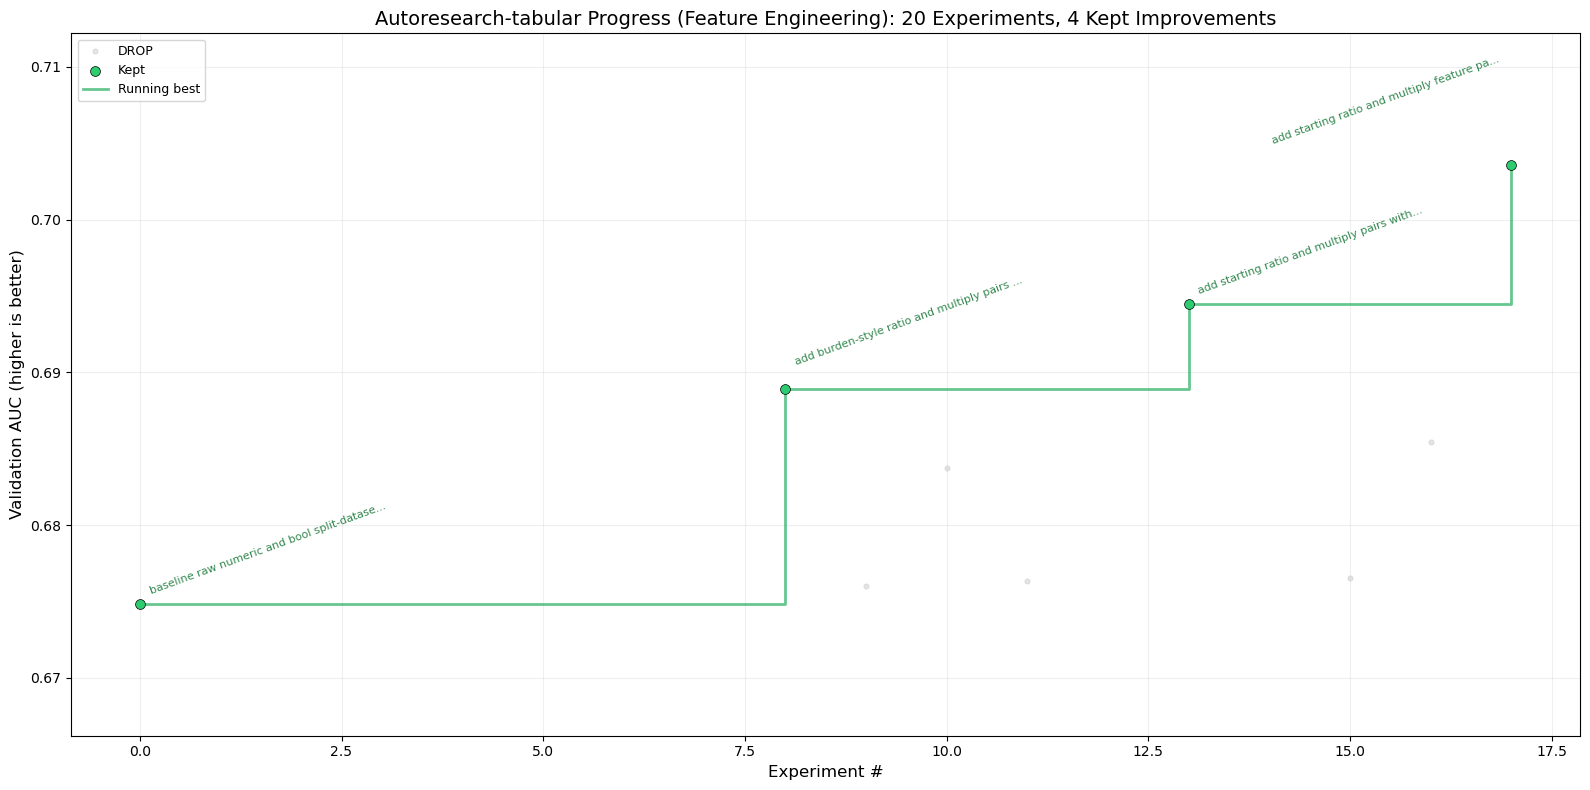

Saved to progress.png


In [32]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_auc = valid.loc[0, "val_auc"]

# Only plot points at or above baseline (the interesting region)
above = valid[valid["val_auc"] >= baseline_auc - 0.0005]

# Plot discarded as faint background dots
disc = above[above["status"] == "DROP"]
ax.scatter(disc.index, disc["val_auc"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="DROP")

# Plot kept experiments as prominent green dots
kept_v = above[above["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["val_auc"],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running maximum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_auc = valid.loc[kept_mask, "val_auc"]
running_best = kept_auc.cummax()
best = running_best.max()
ax.step(kept_idx, running_best, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Label each kept experiment with its description
last_idx = kept_idx.max()
for j, (idx, auc) in enumerate(zip(kept_idx, kept_auc)):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    if idx >= last_idx - 1:
        xytext = (-8, 8 + 6 * (j % 2))
        ha = "right"
    else:
        xytext = (6, 6 + 10 * (j % 2))
        ha = "left"

    ax.annotate(desc, (idx, auc),
                textcoords="offset points",
                xytext=xytext, fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                rotation=20, ha=ha, va="bottom")

n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Validation AUC (higher is better)", fontsize=12)
ax.set_title(f"Autoresearch-tabular Progress (Feature Engineering): {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.2)

# Y-axis: from just below baseline to just above best
margin = (best - baseline_auc) * 0.3
margin = max(margin, 0.0004)
ax.set_ylim(baseline_auc - margin, best + margin)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [33]:
# Summary stats
kept = df[df["status"] == "KEEP"].copy()
baseline_auc = df.iloc[0]["val_auc"]
best_auc = kept["val_auc"].max()
best_row = kept.loc[kept["val_auc"].idxmax()]

print(f"Baseline val_auc: {baseline_auc:.6f}")
print(f"Best val_auc: {best_auc:.6f}")
print(f"Total improvement: {best_auc - baseline_auc:.6f} ({(best_auc - baseline_auc) / baseline_auc * 100:.2f}%)")
print(f"Best experiment: {best_row['description']}")
print()

# How many experiments to find each improvement
print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for i, (_, row) in enumerate(kept_sorted.iterrows()):
    desc = str(row["description"]).strip()
    print(f" Experiment #{row['index']:3d}: auc={row['val_auc']:.6f} {desc}")

Baseline val_auc: 0.674828
Best val_auc: 0.703574
Total improvement: 0.028746 (4.26%)
Best experiment: add starting ratio and multiply feature pairs with numeric missing flags

Cumulative effort per improvement:
 Experiment #  0: auc=0.674828 baseline raw numeric and bool split-dataset features
 Experiment #  8: auc=0.688911 add burden-style ratio and multiply pairs with a 128-feature cap and no missing flags
 Experiment # 13: auc=0.694468 add starting ratio and multiply pairs with no feature cap and no missing flags
 Experiment # 17: auc=0.703574 add starting ratio and multiply feature pairs with numeric missing flags


## Top Hits (Kept Experiments by Improvement)

In [34]:
# Each kept experiment's delta is measured vs the previous kept experiment's auc
# (since experiments are cumulative -- each one builds on the last kept state)
kept = df[df["status"] == "KEEP"].copy()
kept["prev_auc"] = kept["val_auc"].shift(1)
kept["delta"] = kept["val_auc"] - kept["prev_auc"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()

# Sort by delta improvement (biggest first)
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4} {'Delta':>8} {'AUC':>10} Description")
print("-" * 80)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d} {row['delta']:+.6f} {row['val_auc']:.6f} {row['description']}")

print(f"\n{'':>4} {hits['delta'].sum():+.6f} {'':>10} TOTAL improvement over baseline")

Rank    Delta        AUC Description
--------------------------------------------------------------------------------
   1 +0.014083 0.688911 add burden-style ratio and multiply pairs with a 128-feature cap and no missing flags
   2 +0.009106 0.703574 add starting ratio and multiply feature pairs with numeric missing flags
   3 +0.005557 0.694468 add starting ratio and multiply pairs with no feature cap and no missing flags

     +0.028746            TOTAL improvement over baseline
